<a href="https://colab.research.google.com/github/farahrhma/tugasclustering-tugas5/blob/main/FarahRahmaF_Clustering_2304020010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.style.use("default")
sns.set()

Mengimpor library yang digunakan untuk pengolahan data, analisis, dan visualisasi. Pandas dan numpy untuk pengolahan data, serta matplotlib dan seaborn untuk visualisasi. Library tambahan dari scikit-learn juga digunakan untuk proses clustering.

# ETL + EDA

Export Dataset

In [ ]:
df = pd.read_csv('store_customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


Dataset ini berisi informasi pelanggan seperti jenis kelamin, umur, pendapatan tahunan, dan skor pengeluaran yang akan digunakan untuk segmentasi berdasarkan perilaku belanja.

In [ ]:
df.shape

(1000, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


Dilakukan eksplorasi awal untuk memahami struktur data dan mengetahui adanya missing value. Terdapat beberapa missing value pada beberapa kolom seperti Gender, Age, Annual Income, dan Spending Score.

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


# Cleaning & Rename Columns

Drop NA

In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [ ]:
df.dropna(inplace=True)
df.shape

(982, 5)

Data yang memiliki nilai kosong dihapus agar tidak mempengaruhi hasil clustering. Oleh karena itu, dilakukan data cleaning dengan menghapus baris yang memiliki nilai kosong. Setelah proses ini, jumlah data menjadi 982 baris.

Rename Columns

In [ ]:
df = df.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
})

Mengganti nama kolom agar lebih sederhana.

Drop CustomerID

In [ ]:
df = df.drop(columns=["CustomerID"])
df.shape

(982, 4)

Menghapus kolom CustomerID, kolom CustomerID tidak digunakan karena tidak memiliki pengaruh terhadap pola clustering.

In [ ]:
df.head()

,Gender,Age,AnnualIncome,SpendingScore
0,M,39.0,59.9,58.0
1,M,34.0,48.4,37.0
2,F,40.0,70.5,26.0
3,F,47.0,81.1,30.0
4,F,33.0,42.1,58.0


Mapping Gender

M => 1

F => 0

In [ ]:
df["Gender"] = df["Gender"].map({'M':1, 'F':0})

In [ ]:
df["Gender"].value_counts()

,count
Gender,
0,511
1,471


Laki-laki diubah menjadi 1 dan perempuan menjadi 0.

Dilakukan encoding agar data kategorikal bisa diproses oleh algoritma machine learning. Hal ini dilakukan karena algoritma machine learning hanya dapat memproses data numerik.

# Exploratory Data Analysis (EDA)

Distribution of features

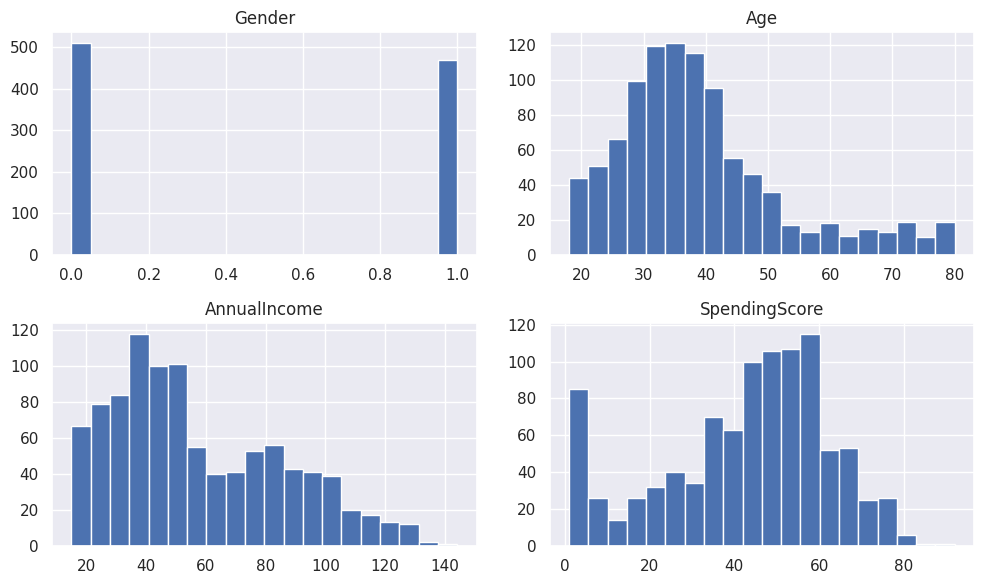

In [ ]:
df.hist(figsize=(10,6), bins=20)
plt.tight_layout()
plt.show()

Visualisasi digunakan untuk melihat apakah terdapat pola atau kecenderungan terbentuknya cluster. Berdasarkan hasil visualisasi histogram, terlihat bahwa variabel Annual Income dan Spending Score memiliki distribusi yang tidak merata dan cenderung membentuk beberapa kelompok. Hal ini menunjukkan adanya perbedaan karakteristik pelanggan berdasarkan tingkat pendapatan dan pola pengeluaran. Oleh karena itu, data memiliki potensi untuk dilakukan proses clustering guna mengelompokkan pelanggan ke dalam segmen-segmen tertentu.

Key Scatters

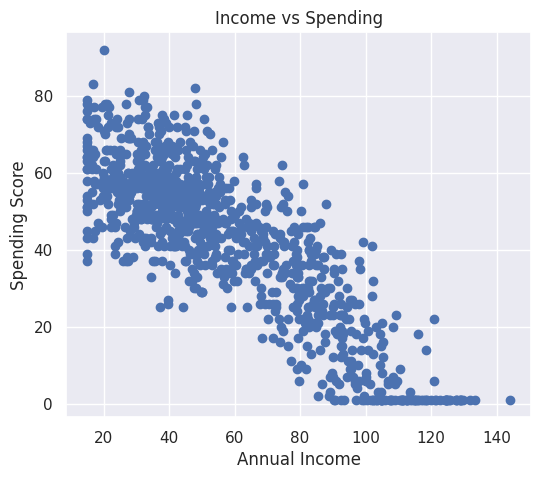

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df["AnnualIncome"],df["SpendingScore"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

Dipilih dua variabel utama karena paling relevan untuk segmentasi pelanggan. Berdasarkan scatter plot antara Annual Income dan Spending Score, terlihat adanya pola hubungan negatif, di mana peningkatan pendapatan cenderung diikuti dengan penurunan skor pengeluaran. Selain itu, titik-titik data membentuk beberapa kecenderungan kelompok, seperti pelanggan dengan pendapatan rendah namun pengeluaran tinggi, serta pelanggan dengan pendapatan tinggi namun pengeluaran rendah. Pola ini menunjukkan adanya segmentasi alami dalam data, sehingga metode clustering seperti K-Means relevan untuk digunakan.

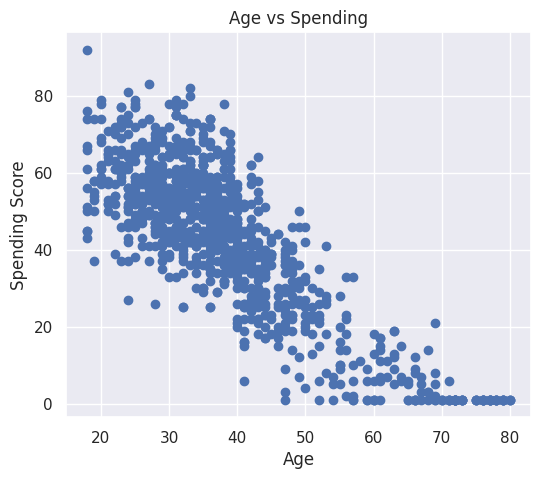

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df["Age"],df["SpendingScore"])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending")
plt.show()

Berdasarkan scatter plot antara Age dan Spending Score, terlihat adanya hubungan negatif yang cukup kuat, di mana semakin tinggi usia pelanggan maka semakin rendah skor pengeluarannya. Selain itu, data membentuk beberapa kelompok yang cukup jelas, seperti kelompok usia muda dengan tingkat pengeluaran tinggi, serta kelompok usia lanjut dengan tingkat pengeluaran rendah. Hal ini menunjukkan adanya segmentasi alami berdasarkan usia, sehingga variabel ini relevan untuk digunakan dalam proses clustering.

# Feature Selection

Preparing X

In [ ]:
X = df[["AnnualIncome","SpendingScore"]].values
X

array([[ 59.9,  58. ],
       [ 48.4,  37. ],
       [ 70.5,  26. ],
       ...,
       [ 67.7,  26. ],
       [ 45.7,  59. ],
       [107.8,   1. ]])

Dilakukan feature selection dengan memilih dua variabel utama, yaitu Annual Income dan Spending Score, karena kedua variabel ini paling merepresentasikan perilaku pelanggan.

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.0898333 ,  0.76554926],
       [-0.31164181, -0.27864393],
       [ 0.45988863, -0.82560227],
       ...,
       [ 0.36213816, -0.82560227],
       [-0.40590119,  0.81527275],
       [ 1.76206444, -2.06868941]])

Dilakukan scaling data menggunakan StandardScaler. Hal ini penting karena algoritma seperti K-Means sangat sensitif terhadap skala data.

Dilakukan normalisasi agar semua fitur memiliki skala yang sama sehingga tidak bias.

# Model Selection

K-Means

Finding the number of clusters.

K-Means digunakan sebagai metode utama clustering, dengan jumlah cluster sebanyak 5 yang ditentukan menggunakan Elbow Method dan Silhouette Score.

Elbow method

In [ ]:
from sklearn.cluster import KMeans
inertia = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
inertia

[1963.9999999999977,
 627.4437722304637,
 380.7047487967602,
 277.4085012407077,
 227.12730374808615,
 193.01427417923557,
 160.2752354182178,
 141.9284308202653,
 127.74877627093812,
 115.97961447218823]

Nilai inertia menurun seiring bertambahnya cluster, dan titik optimal dipilih saat penurunannya mulai melambat.

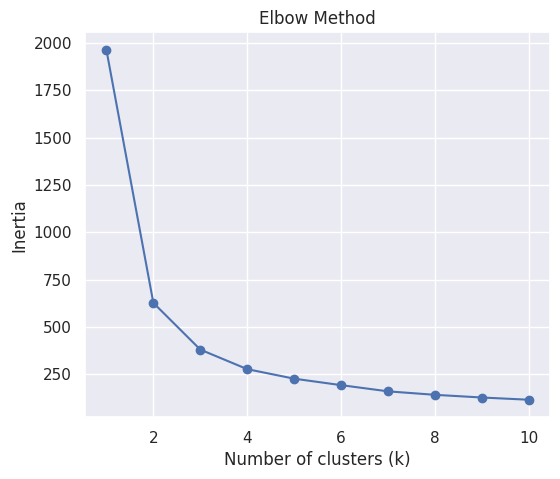

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Dari grafik Elbow, terlihat bahwa titik optimal berada di sekitar 5 cluster.

Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
sil_scores = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
sil_scores

[np.float64(0.5882647596002428),
 np.float64(0.474956222630729),
 np.float64(0.3957499299556574),
 np.float64(0.36362726099229903),
 np.float64(0.3634749904887551),
 np.float64(0.3732245755293607),
 np.float64(0.36009775587028675),
 np.float64(0.35410879741907947),
 np.float64(0.3537239290234216)]

Silhouette score digunakan untuk mengevaluasi seberapa baik data terkelompok.

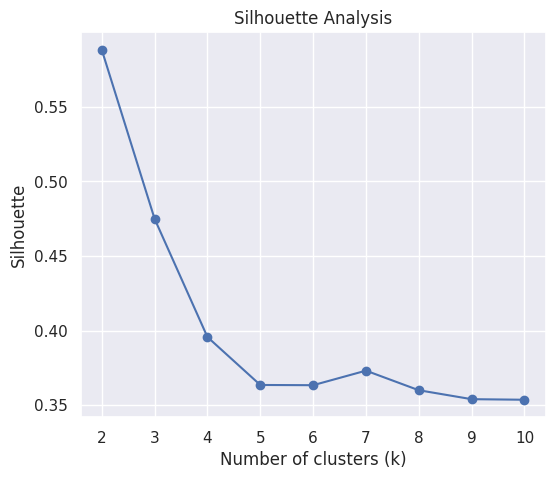

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette")
plt.title("Silhouette Analysis")
plt.show()

Nilai silhouette score juga menunjukkan hasil yang cukup baik pada jumlah cluster tersebut. Oleh karena itu, dipilih 5 cluster sebagai jumlah yang digunakan dalam model.

Training Model

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, init='random')
labels_kmeans = kmeans.fit_predict(X_scaled)
kmeans

KMeans(init='random', n_clusters=5, n_init=10, random_state=42)

In [ ]:
df["KMeans_Cluster"] = labels_kmeans
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster
0,1,39.0,59.9,58.0,3,3
1,1,34.0,48.4,37.0,3,3
2,0,40.0,70.5,26.0,0,0
3,0,47.0,81.1,30.0,0,0
4,0,33.0,42.1,58.0,2,2


K-Means digunakan untuk mengelompokkan pelanggan berdasarkan kemiripan pola belanja. Dilakukan proses clustering menggunakan algoritma K-Means. Hasilnya, setiap data pelanggan berhasil dikelompokkan ke dalam 5 cluster berdasarkan kemiripan karakteristiknya.

Visualization

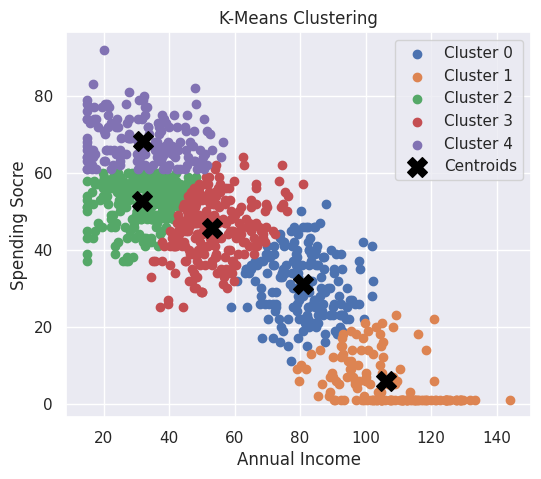

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_kmeans):
    plt.scatter(
        X[labels_kmeans == cluster, 0],
        X[labels_kmeans == cluster, 1],
        label=f"Cluster {cluster}"
    )

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

Hasil clustering kemudian divisualisasikan menggunakan scatter plot, di mana setiap warna menunjukkan kelompok pelanggan yang berbeda dan titik centroid (X) ditandai sebagai pusat cluster. Dari visualisasi ini terlihat bahwa pengelompokan data cukup jelas.

Clusters Analysis

In [ ]:
df.groupby("KMeans_Cluster")[["AnnualIncome","SpendingScore","Age"]].mean()

,AnnualIncome,SpendingScore,Age
KMeans_Cluster,,,
0,80.997849,31.075269,45.026882
1,106.266197,5.753521,64.584507
2,31.818219,52.789474,28.809717
3,53.187097,45.673387,36.266129
4,32.012579,68.389937,28.937107


Setiap cluster dianalisis berdasarkan rata-rata income, spending, dan usia. Dari hasil tersebut, dapat diidentifikasi karakteristik tiap kelompok pelanggan, seperti pelanggan dengan pengeluaran tinggi, pelanggan dengan pendapatan tinggi namun pengeluaran rendah, dan sebagainya.

Customer Segmentation

In [ ]:
import pandas as pd

cluster_stats = df.groupby("KMeans_Cluster")[["AnnualIncome", "SpendingScore", "Age"]].mean().reset_index()

norm = cluster_stats.copy()
for col in ["AnnualIncome", "SpendingScore", "Age"]:
    norm[col] = (norm[col] - norm[col].min()) / (norm[col].max() - norm[col].min())

norm["BusinessScore"] = (
    0.45 * norm["AnnualIncome"] +
    0.45 * norm["SpendingScore"] -
    0.10 * norm["Age"]
)

norm = norm.sort_values("BusinessScore", ascending=False).reset_index(drop=True)

labels = [
    ("⭐⭐⭐⭐⭐", "Best"),
    ("⭐⭐⭐⭐", "Potential"),
    ("⭐⭐⭐", "Sustainable"),
    ("⭐⭐", "High Risk"),
    ("⭐", "Low Value")
]

norm["Business Value"] = [l[0] for l in labels]
norm["Behavior"] = [l[1] for l in labels]

final_table = norm[["KMeans_Cluster", "Business Value", "Behavior"]] \
    .rename(columns={"KMeans_Cluster": "Cluster"})

final_table

,Cluster,Business Value,Behavior
0,4,⭐⭐⭐⭐⭐,Best
1,0,⭐⭐⭐⭐,Potential
2,3,⭐⭐⭐,Sustainable
3,1,⭐⭐,High Risk
4,2,⭐,Low Value


Selanjutnya, dilakukan segmentasi pelanggan dengan membuat Business Score berdasarkan kombinasi pendapatan, pengeluaran, dan umur. Berdasarkan skor tersebut, cluster dikategorikan menjadi beberapa kelompok seperti Best, Potential, Sustainable, High Risk, dan Low Value. Hal ini bertujuan untuk membantu pengambilan keputusan dalam strategi bisnis.

# K-Means++

Selain menggunakan K-Means biasa, dilakukan juga K-Means++ sebagai variasi dari metode K-Means.

In [ ]:
kmeans_pp = KMeans(n_clusters=5, random_state=42, n_init=10, init='k-means++')
labels_kmeans_pp = kmeans_pp.fit_predict(X_scaled)
kmeans_pp

KMeans(n_clusters=5, n_init=10, random_state=42)

K-Means++ digunakan dengan jumlah cluster sebanyak 5, sama seperti K-Means sebelumnya, sehingga hasilnya dapat dibandingkan secara langsung.

In [ ]:
df["KMeansPP_Cluster"] = labels_kmeans_pp
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster,KMeansPP_Cluster
0,1,39.0,59.9,58.0,3,3,1
1,1,34.0,48.4,37.0,3,3,1
2,0,40.0,70.5,26.0,0,0,2
3,0,47.0,81.1,30.0,0,0,2
4,0,33.0,42.1,58.0,2,2,3


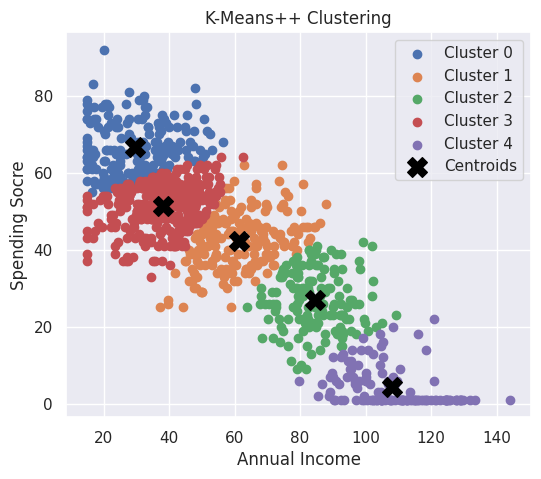

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_kmeans_pp):
    plt.scatter(
        X[labels_kmeans_pp == cluster, 0],
        X[labels_kmeans_pp == cluster, 1],
        label=f"Cluster {cluster}"
    )

centers = scaler.inverse_transform(kmeans_pp.cluster_centers_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("K-Means++ Clustering")
plt.legend()
plt.show()

Dari hasil visualisasi, terlihat bahwa pola cluster yang dihasilkan oleh K-Means++ tidak jauh berbeda dengan K-Means, namun posisi centroid cenderung lebih representatif terhadap masing-masing kelompok data.

# Comparing K-means vs K-means++

In [ ]:
comparision = pd.DataFrame({
    "Method" : ["K-Means", "K-Means++"],
    "Inertia": [kmeans.inertia_,kmeans_pp.inertia_],
    "Silhouette": [
        silhouette_score(X_scaled, labels_kmeans),
        silhouette_score(X_scaled, labels_kmeans_pp)
    ]
})

comparision

,Method,Inertia,Silhouette
0,K-Means,228.838938,0.368901
1,K-Means++,227.127304,0.363627


Meskipun K-Means++ memiliki nilai inertia yang lebih baik, nilai silhouette sedikit lebih rendah dibandingkan K-Means. Hal ini menunjukkan bahwa K-Means++ menghasilkan cluster yang lebih kompak, tetapi tidak selalu memiliki pemisahan antar cluster yang lebih baik. Namun, secara umum K-Means++ lebih stabil karena metode inisialisasi centroid yang lebih baik.

# Hierarchical Clustering (Agglomerative)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

Metode ini membentuk cluster secara bertahap dari bawah ke atas.

Building Dendrogram

Untuk menentukan jumlah cluster yang optimal, digunakan dendrogram, yaitu diagram berbentuk pohon yang menunjukkan proses penggabungan antar data. Dari dendrogram tersebut, dapat dilihat jarak antar cluster dan membantu dalam menentukan jumlah cluster yang sesuai.

In [ ]:
linked = linkage(X_scaled, method='ward')

Digunakan metode linkage Ward, yang menggabungkan cluster berdasarkan minimisasi varians dalam cluster. Metode ini cenderung menghasilkan cluster yang lebih kompak.

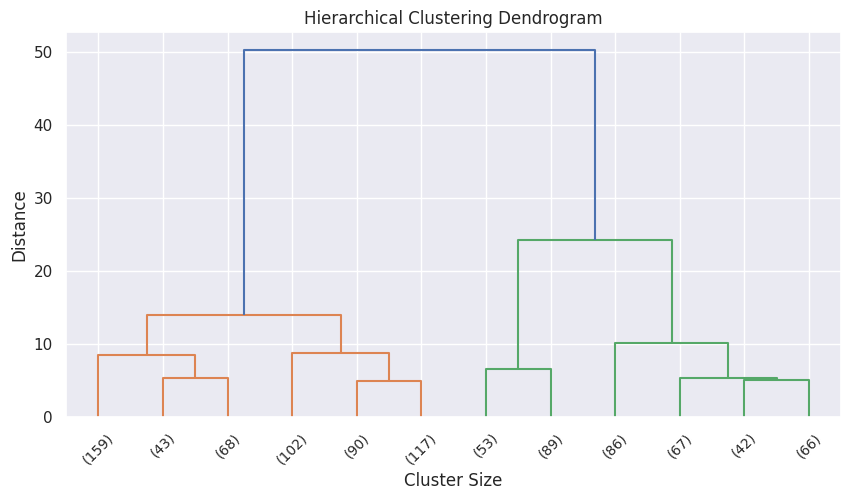

In [ ]:
plt.figure(figsize=(10,5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

Dari dendrogram ini, terlihat adanya lonjakan jarak yang cukup besar pada bagian atas, yang menunjukkan batas alami antar cluster. Dengan menarik garis horizontal sebelum lonjakan tersebut, dapat ditentukan jumlah cluster yang optimal, yaitu sekitar 5 cluster.

In [ ]:
hier = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

labels_hier = hier.fit_predict(X_scaled)

In [ ]:
df["Hierarchical_Cluster"] = labels_hier
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster,KMeansPP_Cluster,Hierarchical_Cluster
0,1,39.0,59.9,58.0,3,3,1,1
1,1,34.0,48.4,37.0,3,3,1,1
2,0,40.0,70.5,26.0,0,0,2,3
3,0,47.0,81.1,30.0,0,0,2,4
4,0,33.0,42.1,58.0,2,2,3,1


Visualization

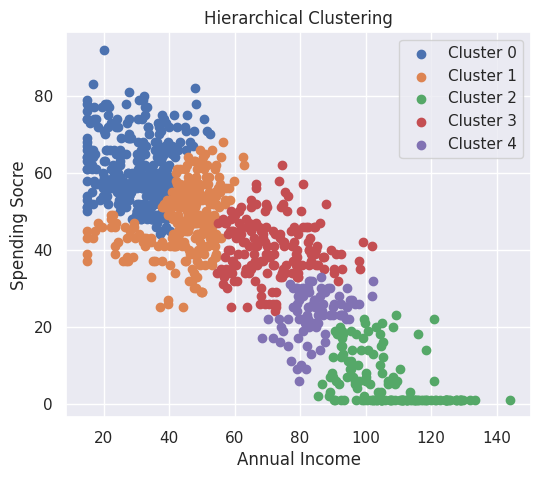

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_hier):
    plt.scatter(
        X[labels_hier == cluster, 0],
        X[labels_hier == cluster, 1],
        label=f"Cluster {cluster}"
    )


plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("Hierarchical Clustering")
plt.legend()
plt.show()

Hasilnya mirip dengan K-Means, namun Hierarchical Clustering tidak memerlukan inisialisasi centroid dan memberikan struktur hubungan antar data melalui dendrogram.

# DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

DBSCAN mengelompokkan data berdasarkan kepadatan titik, serta mampu mendeteksi noise atau outlier. DBSCAN tidak perlu menentukan jumlah cluster, tetapi sensitif terhadap parameter eps.

In [ ]:
dbscan = DBSCAN(
    eps = 0.3,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)

In [ ]:
np.unique(labels_dbscan)

array([-1,  0])

Parameter utama dalam DBSCAN adalah epsilon sebagai radius pencarian dan min_samples sebagai jumlah minimum titik dalam suatu cluster.

Visualization

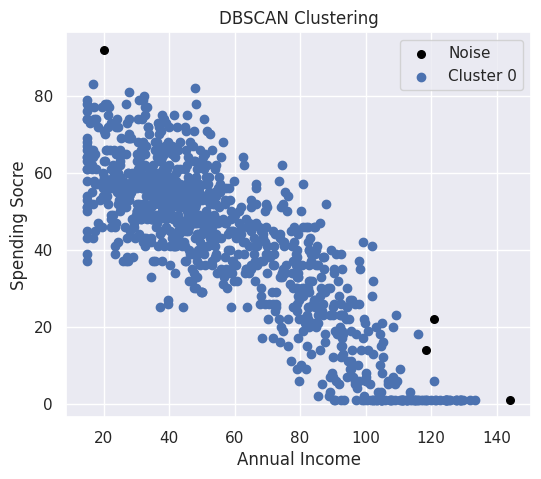

In [ ]:
plt.figure(figsize=(6,5))

for label in np.unique(labels_dbscan):
    if label == -1:
        plt.scatter(
            X[labels_dbscan == label, 0],
            X[labels_dbscan == label, 1],
            label=f"Noise",
            s=30,
            c='black'
        )
    else:
        plt.scatter(
            X[labels_dbscan == label, 0],
            X[labels_dbscan == label, 1],
            label=f"Cluster {label}"
        )


plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()


Pada DBSCAN, scatter plot menunjukkan adanya cluster berdasarkan kepadatan data. Titik berwarna hitam menunjukkan noise atau outlier. Pada hasil ini terlihat bahwa sebagian besar data masuk dalam satu cluster utama, sehingga metode ini kurang optimal untuk dataset ini.

Hasil DBSCAN menunjukkan bahwa hanya terbentuk 1 cluster utama dan beberapa data dianggap sebagai noise. Hal ini menunjukkan bahwa struktur data kurang cocok untuk metode berbasis density dengan parameter yang digunakan.

In [ ]:
mask = labels_dbscan != -1
if len(set(labels_dbscan[mask])) > 1:
    silhouette_score(X_scaled[mask],labels_dbscan[mask])
else:
    print("Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)")

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


In [ ]:
for eps in [0.15, 0.2, 0.3, 0.4, 0.5]:
    labels = DBSCAN(
        eps = eps,
        min_samples=5
    ).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps} => clusters={n_clusters}, noise={n_noise}")

eps=0.15 => clusters=2, noise=65
eps=0.2 => clusters=2, noise=26
eps=0.3 => clusters=1, noise=4
eps=0.4 => clusters=1, noise=1
eps=0.5 => clusters=1, noise=0


Nilai silhouette score tidak dapat dihitung secara optimal karena jumlah cluster yang terbentuk sangat sedikit.

# MeanShift

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth

MeanShift mengelompokkan data berdasarkan kepadatan tanpa perlu menentukan jumlah cluster.

In [ ]:
bandwidth = estimate_bandwidth(
    X_scaled,
    quantile=0.15,
    n_samples=200
)

bandwidth

np.float64(0.6581220328072916)

In [ ]:
meanshift = MeanShift(
    bandwidth=bandwidth,
    bin_seeding = True
)

labels_ms= meanshift.fit_predict(X_scaled)

In [ ]:
np.unique(labels_ms)

array([0, 1, 2])

Bandwidth ditentukan secara otomatis menggunakan fungsi estimate_bandwidth. Hasilnya, metode MeanShift menghasilkan 3 cluster.

Visualization

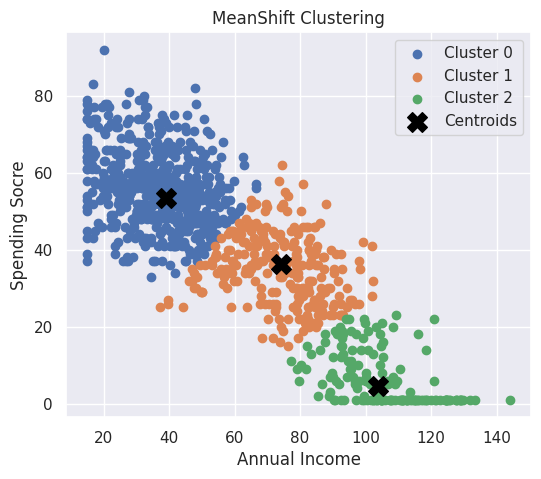

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_ms):
    plt.scatter(
        X[labels_ms == cluster, 0],
        X[labels_ms == cluster, 1],
        label=f"Cluster {cluster}"
    )

centers = scaler.inverse_transform(meanshift.cluster_centers_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("MeanShift Clustering")
plt.legend()
plt.show()

Scatter plot ini menunjukkan hasil clustering menggunakan MeanShift. Terlihat bahwa jumlah cluster terbentuk secara otomatis berdasarkan kepadatan data. Titik hitam menunjukkan pusat cluster, dan terlihat bahwa data dikelompokkan berdasarkan area dengan kepadatan tinggi.

In [ ]:
silhouette_score(X_scaled,labels_ms)

np.float64(0.4981926062529036)

Dari evaluasi menggunakan silhouette score, MeanShift menghasilkan nilai sekitar 0.49, yang menunjukkan bahwa cluster yang terbentuk cukup baik dan memiliki pemisahan yang jelas.

In [ ]:
df["Meanshift_Cluster"] = labels_ms
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster,KMeansPP_Cluster,Hierarchical_Cluster,Meanshift_Cluster
0,1,39.0,59.9,58.0,3,3,1,1,0
1,1,34.0,48.4,37.0,3,3,1,1,0
2,0,40.0,70.5,26.0,0,0,2,3,1
3,0,47.0,81.1,30.0,0,0,2,4,1
4,0,33.0,42.1,58.0,2,2,3,1,0


# Gaussian Mixture Model (GMM)

In [ ]:
from sklearn.mixture import GaussianMixture

selecting the number of components

BIC : Bayesian Information Criterion

AIC : Akaike Information Criterion

GMM memberikan pendekatan probabilistik dalam clustering.

In [ ]:
bic = []
aic = []

ks = range(1,11)

for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))
    aic.append(gmm.aic(X_scaled))
aic, bic

([np.float64(4337.000294876162),
  np.float64(4049.4906835784327),
  np.float64(3252.304558068012),
  np.float64(3254.699415555986),
  np.float64(3258.658696753296),
  np.float64(3259.285983693944),
  np.float64(3260.932779276656),
  np.float64(3253.891525001525),
  np.float64(3261.8414000661915),
  np.float64(3272.1266932852227)],
 [np.float64(4361.448251417934),
  np.float64(4103.276187970332),
  np.float64(3335.427610310038),
  np.float64(3367.1600156481386),
  np.float64(3400.456844695576),
  np.float64(3430.4216794863505),
  np.float64(3461.406022919189),
  np.float64(3483.702316494185),
  np.float64(3520.989739408978),
  np.float64(3560.6125804781364)])

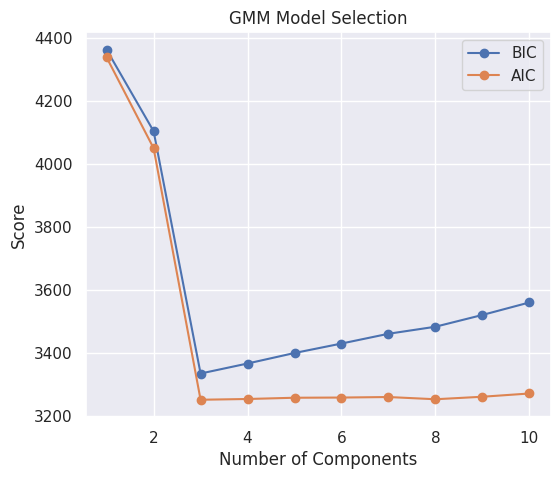

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(ks, bic, marker='o', label='BIC')
plt.plot(ks, aic, marker='o', label='AIC')

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM Model Selection")
plt.legend()
plt.show()

Grafik ini menunjukkan pemilihan jumlah komponen pada model GMM menggunakan AIC dan BIC. Semakin kecil nilainya, semakin baik modelnya.

Terlihat nilai AIC dan BIC turun drastis dari 1 ke 3 komponen, lalu mulai stabil setelahnya. Ini berarti penambahan komponen setelah 3 tidak terlalu meningkatkan kualitas model.

Jadi, jumlah komponen optimal adalah sekitar 3 komponen

Final GMM Model

In [ ]:
gmm = GaussianMixture(
        n_components=3,
        covariance_type='full',
        random_state=42
    )

labels_gmm = gmm.fit_predict(X_scaled)

In [ ]:
df["GMM_Cluster"] = labels_gmm
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster,KMeansPP_Cluster,Hierarchical_Cluster,Meanshift_Cluster,GMM_Cluster
0,1,39.0,59.9,58.0,3,3,1,1,0,1
1,1,34.0,48.4,37.0,3,3,1,1,0,1
2,0,40.0,70.5,26.0,0,0,2,3,1,2
3,0,47.0,81.1,30.0,0,0,2,4,1,2
4,0,33.0,42.1,58.0,2,2,3,1,0,1


Visualization

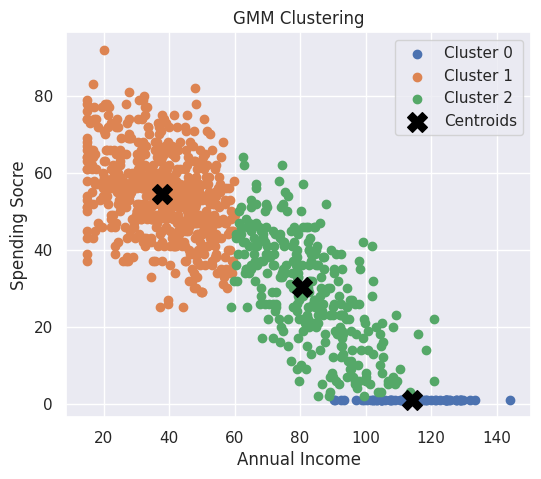

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_gmm):
    plt.scatter(
        X[labels_gmm == cluster, 0],
        X[labels_gmm == cluster, 1],
        label=f"Cluster {cluster}"
    )

centers = scaler.inverse_transform(gmm.means_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("GMM Clustering")
plt.legend()
plt.show()

Scatter plot ini menunjukkan hasil clustering menggunakan Gaussian Mixture Model. Berbeda dengan K-Means, GMM menggunakan pendekatan probabilistik, sehingga batas antar cluster tidak selalu tegas. Titik centroid menunjukkan rata-rata distribusi dari masing-masing cluster.

In [ ]:
probs = gmm.predict_proba(X_scaled)
probs[:5]

array([[0.        , 0.58666149, 0.41333851],
       [0.        , 0.94275725, 0.05724275],
       [0.        , 0.03646948, 0.96353052],
       [0.        , 0.00316162, 0.99683838],
       [0.        , 0.97832832, 0.02167168]])

Dari perbandingan tersebut, K-Means dan K-Means++ memberikan hasil yang stabil dan mudah diinterpretasikan. MeanShift memberikan hasil yang cukup baik tanpa perlu menentukan jumlah cluster. GMM memberikan pendekatan probabilistik yang lebih fleksibel, sedangkan DBSCAN kurang optimal pada dataset ini karena hanya menghasilkan sedikit cluster. Sebagai kesimpulan, data pelanggan menunjukkan adanya pola clustering yang cukup jelas. Metode K-Means dengan 5 cluster dipilih sebagai model yang paling sesuai karena memberikan keseimbangan antara performa dan interpretasi. Hasil segmentasi ini dapat digunakan untuk memahami perilaku pelanggan dan membantu strategi pemasaran yang lebih tepat sasaran.

# Spectral Clustering

In [ ]:
from sklearn.cluster import SpectralClustering

In [ ]:
spectral = SpectralClustering(
    n_clusters=5,
    affinity = 'nearest_neighbors',
    n_neighbors=10,
    random_state=42
)

labels_spec = spectral.fit_predict(X_scaled)

Metode ini bekerja dengan pendekatan berbasis graph, yaitu melihat hubungan antar data berdasarkan kedekatan tetangga terdekat. Spectral Clustering sangat cocok digunakan untuk data yang memiliki pola non-linear atau bentuk cluster yang tidak terpisah secara jelas seperti pada K-Means.

In [ ]:
df["Spectral_Cluster"] = labels_spec
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster,KMeansPP_Cluster,Hierarchical_Cluster,Meanshift_Cluster,GMM_Cluster,Spectral_Cluster
0,1,39.0,59.9,58.0,3,3,1,1,0,1,0
1,1,34.0,48.4,37.0,3,3,1,1,0,1,3
2,0,40.0,70.5,26.0,0,0,2,3,1,2,4
3,0,47.0,81.1,30.0,0,0,2,4,1,2,4
4,0,33.0,42.1,58.0,2,2,3,1,0,1,1


Visualization

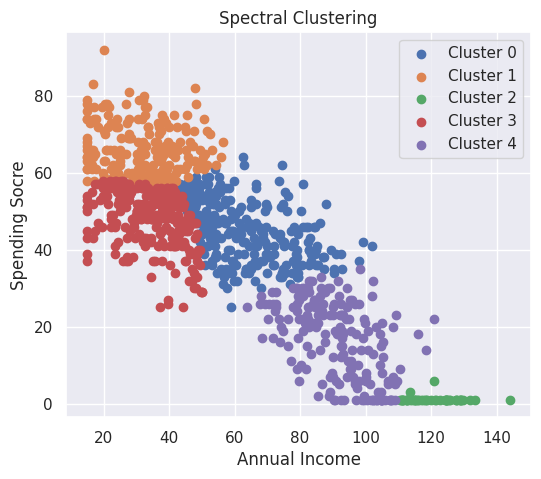

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_spec):
    plt.scatter(
        X[labels_spec == cluster, 0],
        X[labels_spec == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("Spectral Clustering")
plt.legend()
plt.show()

Spectral Clustering digunakan dengan parameter jumlah cluster sebanyak 5 dan menggunakan konsep nearest neighbors. Hasilnya menunjukkan bahwa data tetap dapat dikelompokkan, namun interpretasinya tidak sejelas K-Means.

# Fuzzy C-Means (FCM)

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.2 MB/s eta 0:00:00


In [ ]:
import skfuzzy as fuzz

Berbeda dengan K-Means yang bersifat hard clustering, di mana satu data hanya masuk ke satu cluster, Fuzzy C-Means menggunakan pendekatan soft clustering. Artinya, setiap data memiliki derajat keanggotaan pada setiap cluster dalam bentuk nilai probabilitas atau membership.

In [ ]:
X_fuzzy = X_scaled.T

In [ ]:
centers, final_memb, prim_memb, distances,ofhistory,iter_count,fp_coef = fuzz.cluster.cmeans(
    X_fuzzy,
    c=5,
    m=2,
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)

Hard Label

In [ ]:
labels_fcm = np.argmax(final_memb, axis=0)
df["Fuzzy_Cluster"] = labels_fcm
df.head()

,Gender,Age,AnnualIncome,SpendingScore,Cluster,KMeans_Cluster,KMeansPP_Cluster,Hierarchical_Cluster,Meanshift_Cluster,GMM_Cluster,Spectral_Cluster,Fuzzy_Cluster
0,1,39.0,59.9,58.0,3,3,1,1,0,1,0,4
1,1,34.0,48.4,37.0,3,3,1,1,0,1,3,4
2,0,40.0,70.5,26.0,0,0,2,3,1,2,4,2
3,0,47.0,81.1,30.0,0,0,2,4,1,2,4,2
4,0,33.0,42.1,58.0,2,2,3,1,0,1,1,3


Dengan metode ini, satu pelanggan bisa memiliki kemungkinan berada di beberapa cluster sekaligus, misalnya 70% di cluster A dan 30% di cluster B. Hal ini memberikan fleksibilitas yang lebih tinggi dalam memahami perilaku pelanggan, terutama jika karakteristik pelanggan tidak benar-benar jelas berada di satu kelompok saja.

Namun, dalam praktiknya, untuk kebutuhan segmentasi bisnis yang membutuhkan keputusan yang tegas, biasanya tetap digunakan hasil hard clustering dengan mengambil nilai keanggotaan tertinggi sebagai label cluster.

Visualization

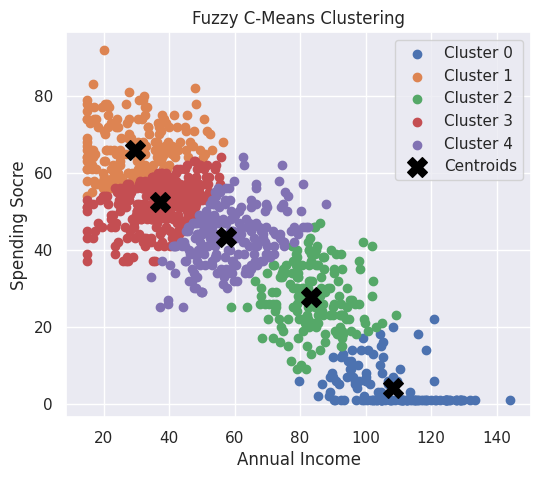

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_fcm):
    plt.scatter(
        X[labels_fcm == cluster, 0],
        X[labels_fcm == cluster, 1],
        label=f"Cluster {cluster}"
    )

centers = scaler.inverse_transform(centers)
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("Fuzzy C-Means Clustering")
plt.legend()
plt.show()

Dari hasil yang diperoleh, Fuzzy C-Means memberikan insight tambahan terkait tingkat kedekatan data terhadap cluster, namun secara visual dan interpretasi, hasilnya masih sejalan dengan metode K-Means.

membership:

In [ ]:
final_memb[:5]

array([[0.02195525, 0.01873881, 0.05130744, ..., 0.05957015, 0.00900354,
        0.98509772],
       [0.1736052 , 0.0530345 , 0.02531178, ..., 0.03357206, 0.25375865,
        0.00124803],
       [0.07572316, 0.07802278, 0.71500698, ..., 0.61976601, 0.02673641,
        0.00891427],
       [0.31652472, 0.18189033, 0.04961542, ..., 0.06764446, 0.5671131 ,
        0.00177657],
       [0.41219166, 0.66831359, 0.15875837, ..., 0.21944732, 0.14338831,
        0.00296341]])

# Customer Segmentation with GMM

Selain menggunakan GMM dengan 3 komponen berdasarkan evaluasi AIC dan BIC, juga dilakukan dengan menggunakan GMM  5 komponen. Hal ini dilakukan untuk menyelaraskan jumlah cluster dengan metode K-Means yang sebelumnya menghasilkan 5 cluster, sehingga hasil segmentasi dapat dibandingkan secara lebih adil dan konsisten dalam konteks bisnis.

In [ ]:
gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42
)

labels_gmm = gmm.fit_predict(X_scaled)

In [ ]:
df["GMM_Cluster"] = labels_gmm

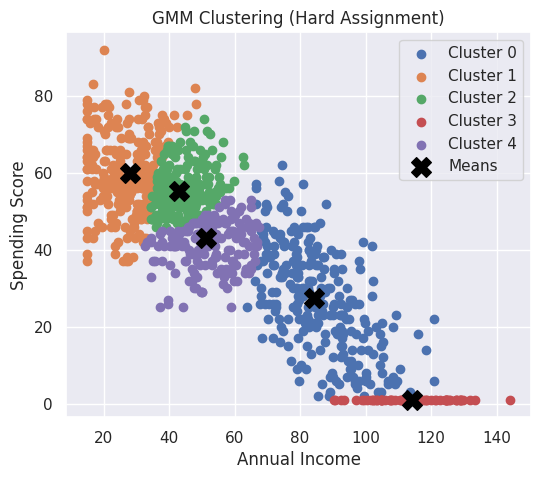

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(labels_gmm):
    plt.scatter(
        X[labels_gmm == cluster, 0],
        X[labels_gmm == cluster, 1],
        label=f"Cluster {cluster}"
    )

centers = scaler.inverse_transform(gmm.means_)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    c="black",
    marker="X",
    label="Means"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("GMM Clustering (Hard Assignment)")
plt.legend()
plt.show()


Soft Clustering

In [ ]:
probs = gmm.predict_proba(X_scaled)
probs[:5]

array([[2.24931431e-01, 5.27935233e-03, 4.72128788e-01, 0.00000000e+00,
        2.97660428e-01],
       [1.26272317e-02, 1.30714353e-02, 9.27267225e-02, 0.00000000e+00,
        8.81574610e-01],
       [8.77094136e-01, 2.40017278e-07, 6.06175955e-06, 0.00000000e+00,
        1.22899562e-01],
       [9.74861443e-01, 4.17569967e-10, 6.23146117e-08, 0.00000000e+00,
        2.51384946e-02],
       [2.83263391e-03, 1.83288541e-01, 7.40046020e-01, 0.00000000e+00,
        7.38328052e-02]])

Pada GMM dengan 5 cluster, dilakukan proses clustering menggunakan pendekatan probabilistik, di mana setiap data tidak hanya diberikan label cluster, tetapi juga memiliki nilai probabilitas keanggotaan terhadap masing-masing cluster.

Amount of uncertainty

In [ ]:
df["GMM_Max_Prob"] = probs.max(axis=1)
df["GMM_Uncertainty"] = 1 - df["GMM_Max_Prob"]
df[["GMM_Max_Prob", "GMM_Uncertainty"]].head()

,GMM_Max_Prob,GMM_Uncertainty
0,0.472129,0.527871
1,0.881575,0.118425
2,0.877094,0.122906
3,0.974861,0.025139
4,0.740046,0.259954


Selanjutnya, dilakukan analisis tambahan berupa nilai maksimum probabilitas atau GMM_Max_Prob untuk melihat tingkat kepercayaan model dalam mengelompokkan data, serta GMM_Uncertainty untuk mengukur tingkat ketidakpastian.

Evaluation

In [ ]:
silhouette_score(X_scaled, labels_gmm)

np.float64(0.26266739121583976)

Selanjutnya, dilakukan analisis tambahan berupa nilai maksimum probabilitas atau GMM_Max_Prob untuk melihat tingkat kepercayaan model dalam mengelompokkan data, serta GMM_Uncertainty untuk mengukur tingkat ketidakpastian. Namun, jika dibandingkan menggunakan silhouette score, nilai yang dihasilkan oleh GMM dengan 5 cluster relatif lebih rendah dibandingkan K-Means, yaitu sekitar 0.26. Hal ini menunjukkan bahwa secara pemisahan cluster, K-Means masih lebih optimal.

Meskipun demikian, GMM memberikan insight tambahan dalam bentuk probabilitas dan ketidakpastian, yang sangat berguna untuk analisis yang lebih mendalam.

In [ ]:
cluster_stats = df.groupby("GMM_Cluster")[["AnnualIncome", "SpendingScore", "Age"]].mean().reset_index()

norm = cluster_stats.copy()

for col in ["AnnualIncome", "SpendingScore", "Age"]:
    norm[col] = (norm[col] - norm[col].min()) / (norm[col].max() - norm[col].min())

norm["BusinessScore"] = (
    0.45 * norm["AnnualIncome"] +
    0.45 * norm["SpendingScore"] -
    0.10 * norm["Age"]
)

norm = norm.sort_values("BusinessScore", ascending=False).reset_index(drop=True)

labels = [
    ("★★★★★", "Best"),
    ("★★★★", "Potential"),
    ("★★★", "Sustainable"),
    ("★★", "High Risk"),
    ("★", "Low Value")
]

norm["Business Value"] = [l[0] for l in labels]
norm["Behavior"] = [l[1] for l in labels]

final_table = norm[["GMM_Cluster", "Business Value", "Behavior"]] \
    .rename(columns={"GMM_Cluster": "Cluster"})

final_table

,Cluster,Business Value,Behavior
0,2,★★★★★,Best
1,0,★★★★,Potential
2,1,★★★,Sustainable
3,4,★★,High Risk
4,3,★,Low Value


Seperti pada K-Means, dilakukan juga proses segmentasi bisnis dengan menghitung Business Score berdasarkan income, spending, dan age. Hasilnya, cluster berhasil dikategorikan menjadi kelompok seperti Best, Potential, Sustainable, High Risk, dan Low Value.

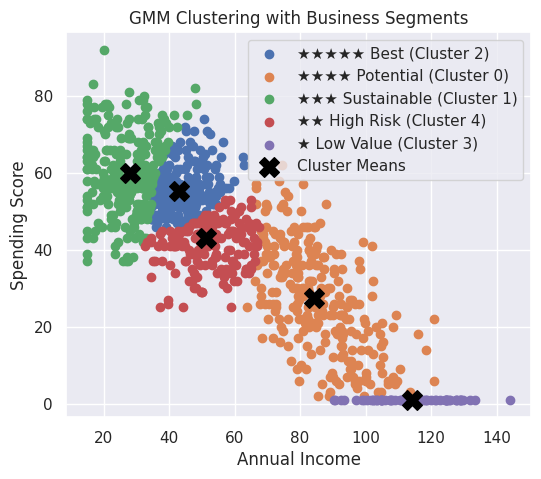

In [ ]:
plt.figure(figsize=(6,5))

centers = scaler.inverse_transform(gmm.means_)

ordered_clusters = final_table["Cluster"].values

for cluster in ordered_clusters:

    row = final_table[final_table["Cluster"] == cluster].iloc[0]

    stars = row["Business Value"]
    behavior = row["Behavior"]

    plt.scatter(
        X[labels_gmm == cluster, 0],
        X[labels_gmm == cluster, 1],
        label=f"{stars} {behavior} (Cluster {cluster})"
    )

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c="black",
    marker="X",
    label="Cluster Means"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("GMM Clustering with Business Segments")

plt.legend()
plt.show()


Visualisasi akhir menunjukkan distribusi cluster beserta label bisnisnya, sehingga memudahkan interpretasi hasil clustering dalam konteks strategi pemasaran.